# Trajectory Generation for Testing

In [23]:
import importlib
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy.random as npr
from shapely.geometry import box
from pprint import pprint

import nomad.city_gen as cg
from nomad.city_gen import City, Building, Street
import nomad.traj_gen as tg
from nomad.traj_gen import Agent, Population
import os
os.environ['TZ'] = 'UTC'

In [24]:
city = cg.load('garden-city.pkl')

In [25]:
city

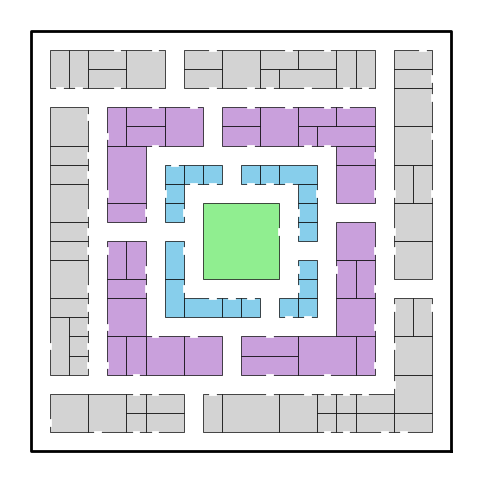

In [26]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(6, 6))
plt.box(on=False)

city.plot_city(ax, doors=True, address=False)

ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_yticks([])

plt.show()

In [27]:
population = Population(city)

In [28]:
start_time = [datetime(2024, 6, 1, hour=0, minute=0) + timedelta(minutes=60*t) for t in range(5)]
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [60]*5  # in minutes

location = ['h-x13-y11'] * 1 + ['h-x13-y8'] * 1 + ['r-x18-y10'] * 3

destination = pd.DataFrame({"unix_timestamp": unix_timestamp,
                            "local_timestamp": start_time,
                            "duration": duration,
                            "location": location})

destination = tg.condense_destinations(destination)

Charlie = Agent(identifier="Charlie",
                home='h-x13-y11',
                workplace='w-x15-y9',
                city=city,
                destination_diary=destination,
                dt=1)

population.add_agent(Charlie)
population.generate_trajectory(Charlie, seed=75)

In [29]:
Charlie.diary

,unix_timestamp,local_timestamp,duration,location,identifier
0,1717200000,2024-06-01 00:00:00,61,h-x13-y11,Charlie
1,1717203660,2024-06-01 01:01:00,2,None,Charlie
2,1717203780,2024-06-01 01:03:00,58,h-x13-y8,Charlie
3,1717207260,2024-06-01 02:01:00,4,None,Charlie
4,1717207500,2024-06-01 02:05:00,176,r-x18-y10,Charlie


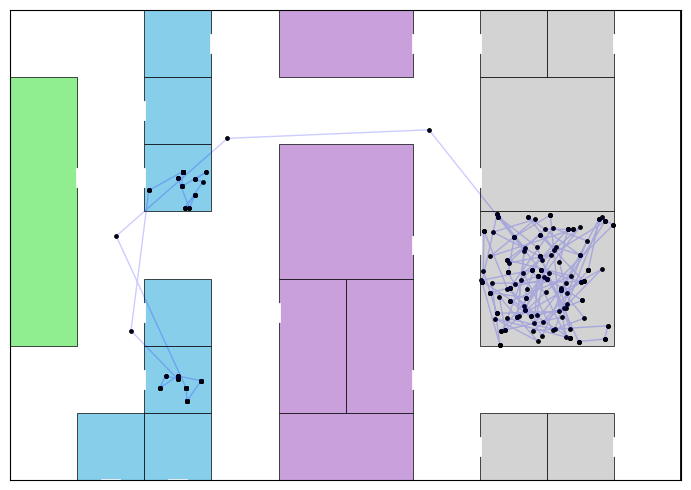

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x=Charlie.trajectory.x, 
           y=Charlie.trajectory.y, 
           s=6, color='black', alpha=1, zorder=2)
city.plot_city(ax, doors=True, address=False, zorder=1)

ax.plot(Charlie.trajectory.x,
        Charlie.trajectory.y,
        linewidth=1, color='blue', alpha=0.2)

ax.set_xlim(12, 22)
ax.set_ylim(7, 14)
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

plt.show()

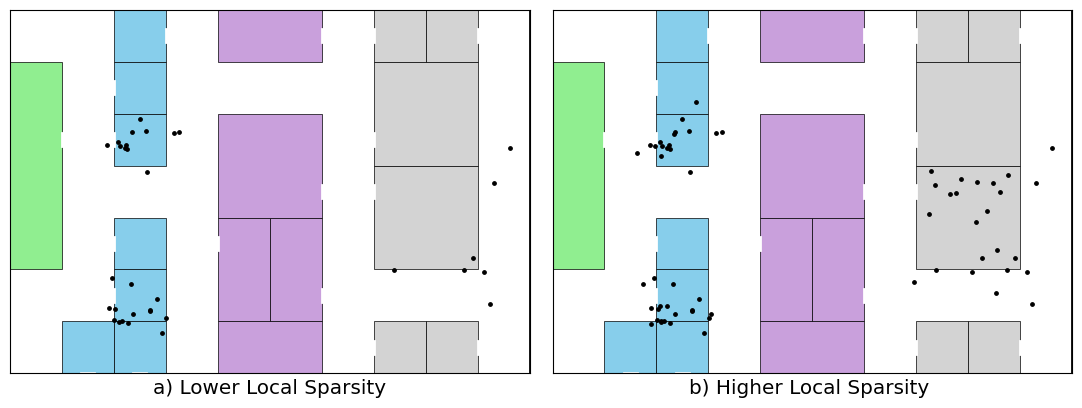

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
hier_nhpp_params = [(150, 20, 2), (60, 40, 10)]
seed = 819

for j in range(2):
    ax = axes[j]
    Charlie.sample_traj_hier_nhpp(*hier_nhpp_params[j], seed=seed)

    ax.scatter(Charlie.sparse_traj.x, Charlie.sparse_traj.y, s=6, color='black', alpha=1, zorder=2)
    city.plot_city(ax, doors=True, address=False, zorder=1)

    ax.set_xlim(12, 22)
    ax.set_ylim(7, 14)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].set_xlabel('a) Lower Local Sparsity', fontsize='x-large')
axes[1].set_xlabel('b) Higher Local Sparsity ', fontsize='x-large')

plt.tight_layout()
plt.show()

In [32]:
start_time = [datetime(2024, 1, 1, hour=0, minute=0) + timedelta(minutes=15*t) for t in range(22)]
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [15]*22  # in minutes
location = ['h-x8-y13'] * 2 + ['r-x12-y3'] * 4 + ['w-x15-y15'] * 12 + ['h-x8-y13'] * 4

d_diary = pd.DataFrame({"unix_timestamp":unix_timestamp,
                        "local_timestamp":start_time,
                        "duration":duration,
                        "location":location})

d_diary = tg.condense_destinations(d_diary)

Alice = Agent(identifier="Alice",
              home='h-x8-y13',
              workplace='w-x15-y15',
              city=city,
              destination_diary=d_diary)

population.add_agent(agent=Alice)
population.generate_trajectory(agent=Alice, seed=100)

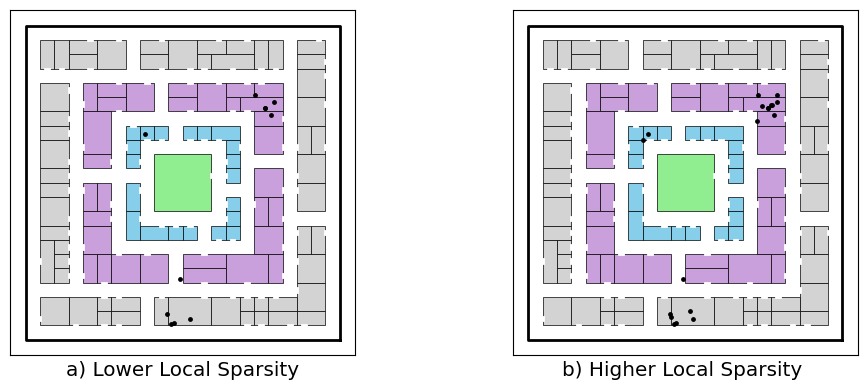

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
hier_nhpp_params = [(150, 20, 2), (60, 40, 10)]
seed = 819

for j in range(2):
    ax = axes[j]
    Alice.sample_traj_hier_nhpp(*hier_nhpp_params[j], seed=seed)

    ax.scatter(Alice.sparse_traj.x, Alice.sparse_traj.y, s=6, color='black', alpha=1, zorder=2)
    city.plot_city(ax, doors=True, address=False, zorder=1)

    # ax.set_xlim(12, 22)
    # ax.set_ylim(7, 14)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].set_xlabel('a) Lower Local Sparsity', fontsize='x-large')
axes[1].set_xlabel('b) Higher Local Sparsity ', fontsize='x-large')

plt.tight_layout()
plt.show()